# SONGS — Large-Dataset visualisation notebook

Loads a dataset produced by the GUI's **Large-Dataset Mode** ("Generate Dataset"): a `dataset.pkl` manifest plus one `raw/` folder containing per-cube HDF5 files. When noise is enabled, each cube has both a `_clean.h5` and a `_noisy.h5` file sharing the same index.

This notebook loads the manifest, picks one cube, and plots its clean vs. noisy central channel side by side.

In [1]:
import os
import pickle
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Path to the dataset.pkl written by the GUI's "Choose Save Folder" + "Generate Dataset".
# raw/ (containing the per-cube HDF5 files) is a sibling of dataset.pkl.
dataset_path = '/Users/arnablahiry/toy_cubes/dataset.pkl'
save_folder  = os.path.dirname(dataset_path)
raw_dir      = os.path.join(save_folder, 'raw')

with open(dataset_path, 'rb') as f:
    dataset = pickle.load(f)

manifest = dataset['manifest']
print(f"n_samples generated: {dataset['n_generated']}/{dataset['n_samples']}")
print(f"use_noise: {dataset['use_noise']}")
print(f"param_limit_frac: {dataset['param_limit_frac']}")
print(f"manifest entries: {len(manifest)}")
manifest[0]

n_samples generated: 1000/1000
use_noise: True
param_limit_frac: 0.2
manifest entries: 1000


{'n_gals': 2,
 'sersic_n': [0.884060110545994, 0.9834347814368724],
 'Re_kpc': [21.62148309146193, 8.986258080881907],
 'hz': [0.7827520969285612, 0.2690147866579135],
 'Se': [0.09683166860573442, 0.07938128778050807],
 'inclination_x_deg': [256.7319100367092, 122.63676498984984],
 'inclination_y_deg': [282.43301564083816, 110.56523688696983],
 'sigma_v_km_s': 44.058266034870115,
 'beam_info_kpc': [11.0, 13.0, 20.0],
 'fov_kpc': 275,
 'spatial_resolution_kpc_per_px': 2.75,
 'spectral_resolution_km_s': 20,
 'diffuse_params': {'enabled': True,
  'halo_Re_factor': 1.8436134004906608,
  'halo_Se_factor': 0.021722061084641017,
  'halo_hz_factor': 2.0,
  'halo_n': 0.5,
  'halo_sigma_vz': 62.66642800892535,
  'bridge_start_frac': 0.2,
  'bridge_stop_frac': 0.0,
  'bridge_width_start_factor': 0.9705170210135684,
  'bridge_width_end_factor': 0.5543526566761686,
  'bridge_edge_fade': 0.1,
  'bridge_Se_factor': 0.028841912134864103,
  'bridge_sigma_vz': 86.65158650650818,
  'tail_length_factor': 

## Load one cube (clean + noisy)

Each manifest entry's `index` matches the `cube_{index:05d}_clean.h5` / `cube_{index:05d}_noisy.h5` filenames in `raw/`. The full per-cube parameter manifest is also embedded in each HDF5 file's `parameters_json` header attribute, so the files are self-describing even without `dataset.pkl`.

In [8]:
cube_index = 800  # pick any index present in raw/ (1-based, matches manifest[i]['index'])

clean_path = os.path.join(raw_dir, f'cube_{cube_index:05d}_clean.h5')
noisy_path = os.path.join(raw_dir, f'cube_{cube_index:05d}_noisy.h5')

with h5py.File(clean_path, 'r') as f:
    clean_cube = f['cube'][:]
    channel_velocities = f['channel_velocities_km_s'][:]

with h5py.File(noisy_path, 'r') as f:
    noisy_cube = f['cube'][:]

print(f"cube shape (n_channels, ny, nx): {clean_cube.shape}")
print(f"peak S/N used for the noisy cube: {manifest[cube_index - 1]['sn_peak']:.2f}")

cube shape (n_channels, ny, nx): (60, 100, 100)
peak S/N used for the noisy cube: 7.61


## Clean vs. noisy — central channel

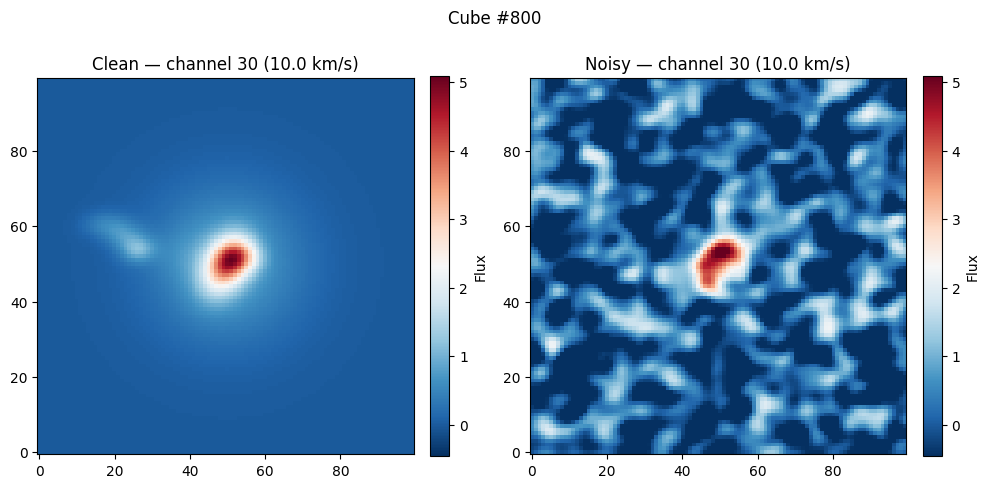

In [11]:
central_ch = clean_cube.shape[0] // 2

fig, (ax_clean, ax_noisy) = plt.subplots(1, 2, figsize=(10, 5))

vmin = min(clean_cube.sum(0).min(), noisy_cube[central_ch].min())
vmax = max(clean_cube.sum(0).max(), noisy_cube[central_ch].max())

im0 = ax_clean.imshow(clean_cube.sum(0), origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
ax_clean.set_title(f'Clean — channel {central_ch} ({channel_velocities[central_ch]:.1f} km/s)')
fig.colorbar(im0, ax=ax_clean, fraction=0.046, pad=0.04, label='Flux')

im1 = ax_noisy.imshow(noisy_cube.sum(0), origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
ax_noisy.set_title(f'Noisy — channel {central_ch} ({channel_velocities[central_ch]:.1f} km/s)')
fig.colorbar(im1, ax=ax_noisy, fraction=0.046, pad=0.04, label='Flux')

fig.suptitle(f'Cube #{cube_index}')
fig.tight_layout()
plt.show()